<a href="https://colab.research.google.com/github/susovit005/MA_LAB_SUBMISSION/blob/main/MA_LAB_EXPERIMENTS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

:EXPERIMENT-1

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



In [ ]:

X = np.array([1, 2, 3]).reshape(-1, 1)
Y = np.array([
    [2, 3],
    [4, 5],
    [6, 7]
])

In [ ]:
model = LinearRegression()
model.fit(X, Y)


LinearRegression()

In [ ]:
Y_pred = model.predict(X)

print("Predicted Output:")
print(Y_pred)


Predicted Output:
[[2. 3.]
 [4. 5.]
 [6. 7.]]


In [ ]:
print("\nCoefficient Matrix (W):")
print(model.coef_)

print("\nIntercept Vector (B):")
print(model.intercept_)



Coefficient Matrix (W):
[[2.]
 [2.]]

Intercept Vector (B):
[8.8817842e-16 1.0000000e+00]


In [ ]:
# MSE, MAE, RMSE
mse = mean_squared_error(Y, Y_pred)
mae = mean_absolute_error(Y, Y_pred)
rmse = np.sqrt(mse)

# R² Score
r2 = r2_score(Y, Y_pred)

# Adjusted R²
n = X.shape[0]     # number of samples
p = X.shape[1]     # number of features

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("\nError Metrics:")
print("MSE      :", mse)
print("MAE      :", mae)
print("RMSE     :", rmse)
print("R²       :", r2)
print("Adj R²   :", adj_r2)



Error Metrics:
MSE      : 3.2869204384208827e-31
MAE      : 4.440892098500626e-16
RMSE     : 5.733167046599011e-16
R²       : 1.0
Adj R²   : 1.0


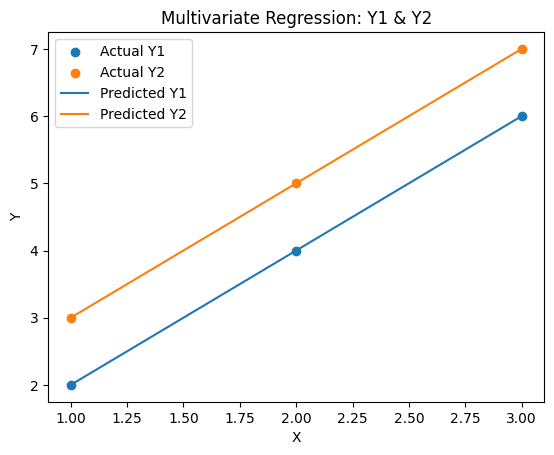

In [ ]:
plt.figure()

# Actual points
plt.scatter(X, Y[:, 0], label='Actual Y1')
plt.scatter(X, Y[:, 1], label='Actual Y2')

# Predicted lines
plt.plot(X, Y_pred[:, 0], label='Predicted Y1')
plt.plot(X, Y_pred[:, 1], label='Predicted Y2')

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Multivariate Regression: Y1 & Y2")
plt.legend()
plt.show()



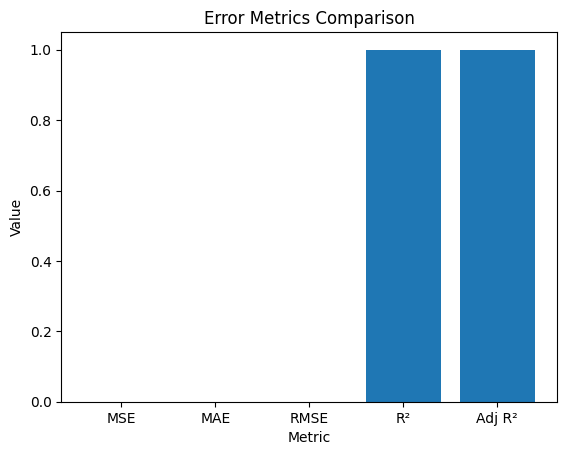

In [ ]:
errors = [mse, mae, rmse, r2, adj_r2]
labels = ['MSE', 'MAE', 'RMSE', 'R²', 'Adj R²']

plt.figure()
plt.bar(labels, errors)
plt.title("Error Metrics Comparison")
plt.xlabel("Metric")
plt.ylabel("Value")
plt.show()


experiment 4


In [ ]:
import numpy as np

X = np.array([
    [1,1],
    [2,1],
    [2,3],
    [3,3]
])

y = np.array([1,1,-1,-1])

w = np.array([0, -1])
b = 2

def predict(x):
    return np.sign(np.dot(w, x) + b)

for i in range(len(X)):
    value = y[i] * (np.dot(w, X[i]) + b)
    print(f"Point {X[i]} constraint value: {value}")

margin = 2 / np.linalg.norm(w)
print("\nMargin:", margin)

new_point = np.array([2,2])
print("New point classification:", predict(new_point))

Point [1 1] constraint value: 1
Point [2 1] constraint value: 1
Point [2 3] constraint value: 1
Point [3 3] constraint value: 1

Margin: 2.0
New point classification: 0


In [ ]:
import numpy as np

X = np.array([2, 4, 0, 1])
y = np.array([1, 1, -1, -1])

w = 2
b = -3

def decision_function(x):
    return w * x + b

def predict(x):
    return np.sign(decision_function(x))

print("Checking constraints:")
for i in range(len(X)):
    value = y[i] * decision_function(X[i])
    print(f"x = {X[i]}, constraint value = {value}")

margin = 2 / abs(w)
print("\nMargin:", margin)

new_points = [3, 0.5]
for point in new_points:
    print(f"Point {point} classified as:", predict(point))

Checking constraints:
x = 2, constraint value = 1
x = 4, constraint value = 5
x = 0, constraint value = 3
x = 1, constraint value = 1

Margin: 1.0
Point 3 classified as: 1
Point 0.5 classified as: -1.0


Weight vector: [-6.4000e-04 -9.9968e-01]
Bias: 2.0007466666666667


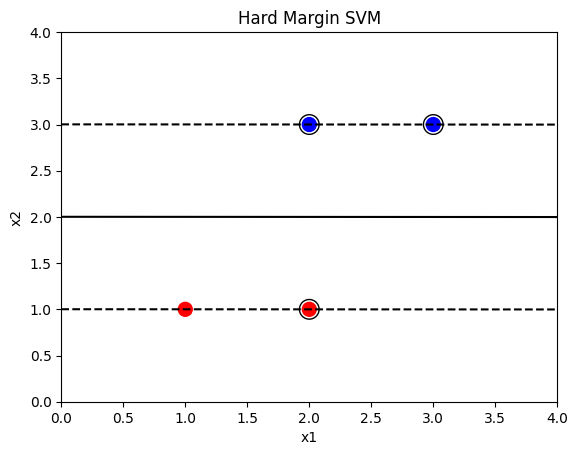

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm

X = np.array([
    [1,1],
    [2,1],
    [2,3],
    [3,3]
])

y = np.array([1,1,-1,-1])

clf = svm.SVC(kernel='linear', C=1e6)
clf.fit(X,y)

w = clf.coef_[0]
b = clf.intercept_[0]

print("Weight vector:", w)
print("Bias:", b)

plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', s=100)

xx = np.linspace(0,4)
yy = -(w[0]*xx + b)/w[1]
plt.plot(xx, yy, 'k-')

yy_down = -(w[0]*xx + b - 1)/w[1]
yy_up = -(w[0]*xx + b + 1)/w[1]
plt.plot(xx, yy_down, 'k--')
plt.plot(xx, yy_up, 'k--')

plt.scatter(clf.support_vectors_[:,0],
            clf.support_vectors_[:,1],
            s=200, facecolors='none', edgecolors='k')

plt.xlim(0,4)
plt.ylim(0,4)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Hard Margin SVM")
plt.show()

Weight (w): 2.0
Bias (b): -3.0


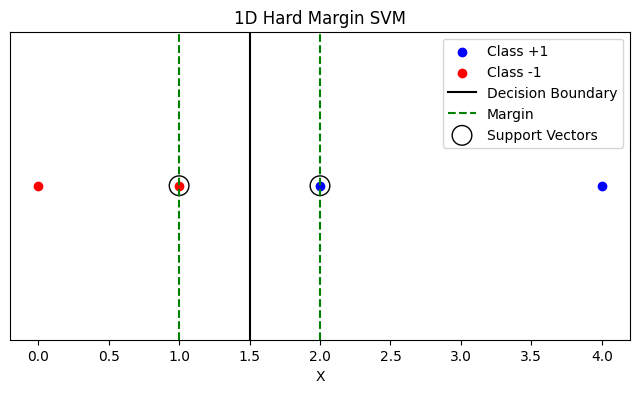

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm

X = np.array([[2],[4],[0],[1]])
y = np.array([1,1,-1,-1])

clf = svm.SVC(kernel='linear', C=1e6)
clf.fit(X, y)

w = clf.coef_[0][0]
b = clf.intercept_[0]

print("Weight (w):", w)
print("Bias (b):", b)

plt.figure(figsize=(8,4))

plt.scatter(X[y==1], np.zeros_like(X[y==1]), color='blue', label='Class +1')
plt.scatter(X[y==-1], np.zeros_like(X[y==-1]), color='red', label='Class -1')

x_vals = np.linspace(-1,5,100)
decision_boundary = (-b)/w

plt.axvline(x=decision_boundary, color='black', label='Decision Boundary')

margin1 = (-b + 1)/w
margin2 = (-b - 1)/w

plt.axvline(x=margin1, linestyle='--', color='green', label='Margin')
plt.axvline(x=margin2, linestyle='--', color='green')

plt.scatter(clf.support_vectors_,
            np.zeros_like(clf.support_vectors_),
            s=200, facecolors='none', edgecolors='black',
            label='Support Vectors')

plt.yticks([])
plt.xlabel("X")
plt.title("1D Hard Margin SVM")
plt.legend()
plt.show()

Weight (w): 2.0
Bias (b): -3.0


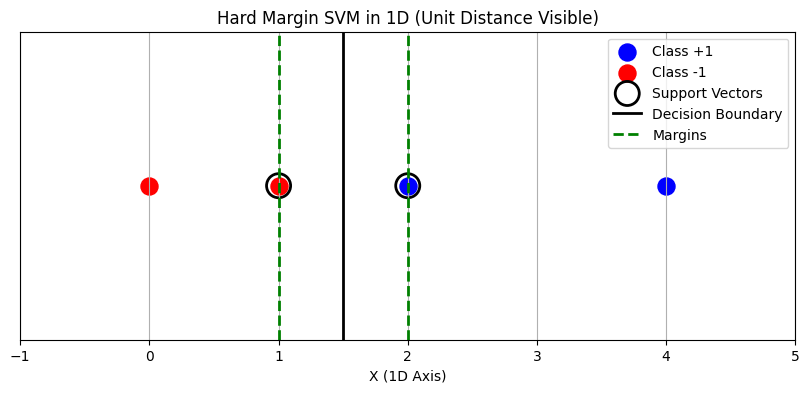

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm

X = np.array([[2],[4],[0],[1]])
y = np.array([1,1,-1,-1])

clf = svm.SVC(kernel='linear', C=1e6)
clf.fit(X, y)

w = clf.coef_[0][0]
b = clf.intercept_[0]

print("Weight (w):", w)
print("Bias (b):", b)

decision_boundary = -b / w
margin_pos = (-b + 1) / w
margin_neg = (-b - 1) / w

plt.figure(figsize=(10,4))

plt.scatter(X[y==1], np.zeros_like(X[y==1]),
            color='blue', s=150, label='Class +1')

plt.scatter(X[y==-1], np.zeros_like(X[y==-1]),
            color='red', s=150, label='Class -1')

plt.scatter(clf.support_vectors_,
            np.zeros_like(clf.support_vectors_),
            s=300, facecolors='none', edgecolors='black',
            linewidth=2, label='Support Vectors')

plt.axvline(decision_boundary, color='black',
            linewidth=2, label='Decision Boundary')

plt.axvline(margin_pos, color='green', linestyle='--',
            linewidth=2, label='Margins')
plt.axvline(margin_neg, color='green', linestyle='--',
            linewidth=2)

plt.yticks([])
plt.xticks(np.arange(-1,6,1))
plt.xlim(-1,5)
plt.ylim(-0.5,0.5)

plt.xlabel("X (1D Axis)")
plt.title("Hard Margin SVM in 1D (Unit Distance Visible)")
plt.grid(True)
plt.legend()
plt.show()

Weight vector: [-6.4000e-04 -9.9968e-01]
Bias: 2.0007466666666667


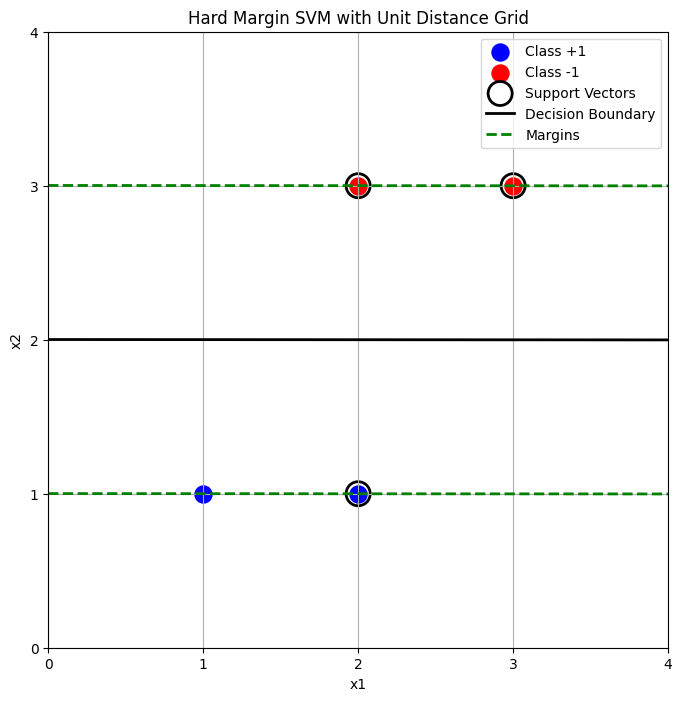

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm

X = np.array([[1,1],
              [2,1],
              [2,3],
              [3,3]])

y = np.array([1,1,-1,-1])

clf = svm.SVC(kernel='linear', C=1e6)
clf.fit(X, y)

w = clf.coef_[0]
b = clf.intercept_[0]

print("Weight vector:", w)
print("Bias:", b)

plt.figure(figsize=(8,8))

plt.scatter(X[y==1][:,0], X[y==1][:,1],
            color='blue', s=150, label='Class +1')

plt.scatter(X[y==-1][:,0], X[y==-1][:,1],
            color='red', s=150, label='Class -1')

plt.scatter(clf.support_vectors_[:,0],
            clf.support_vectors_[:,1],
            s=300, facecolors='none',
            edgecolors='black', linewidth=2,
            label='Support Vectors')

xx = np.linspace(0,4,100)
yy = -(w[0]*xx + b)/w[1]
plt.plot(xx, yy, 'k-', linewidth=2, label='Decision Boundary')

yy_down = -(w[0]*xx + b - 1)/w[1]
yy_up = -(w[0]*xx + b + 1)/w[1]
plt.plot(xx, yy_down, 'g--', linewidth=2, label='Margins')
plt.plot(xx, yy_up, 'g--', linewidth=2)

plt.xticks(np.arange(0,5,1))
plt.yticks(np.arange(0,5,1))
plt.xlim(0,4)
plt.ylim(0,4)

plt.grid(True)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Hard Margin SVM with Unit Distance Grid")
plt.legend()
plt.show()

Weight vector (w): [ 1 -3  0]
Bias (b): -2
Decision value: -4.2
Predicted class: -1


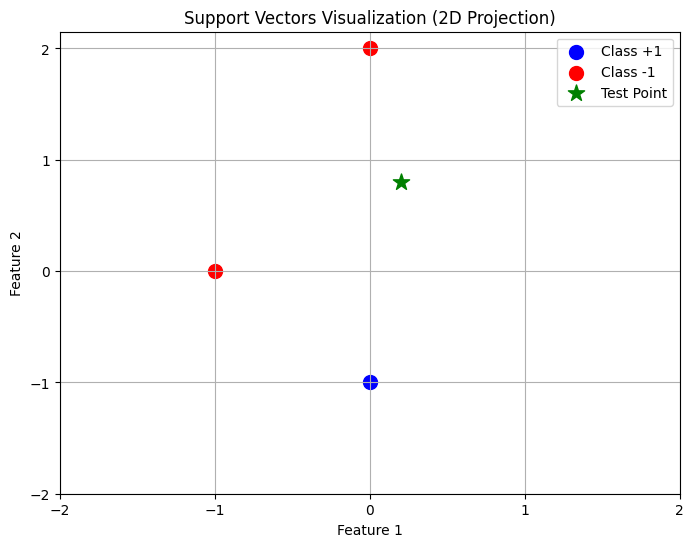

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([
    [0, -1, 1],
    [0, 2, -1],
    [-1, 0, 2]
])

y = np.array([1, -1, -1])
alpha = np.array([1, 1, 1])

w = np.sum(alpha[:, None] * y[:, None] * X, axis=0)

b = y[0] - np.dot(w, X[0])

x_test = np.array([0.2, 0.8, 0.4])

decision_value = np.dot(w, x_test) + b
prediction = np.sign(decision_value)

print("Weight vector (w):", w)
print("Bias (b):", b)
print("Decision value:", decision_value)
print("Predicted class:", int(prediction))

plt.figure(figsize=(8, 6))

plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1],
            color='blue', s=100, label='Class +1')

plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1],
            color='red', s=100, label='Class -1')

plt.scatter(x_test[0], x_test[1],
            color='green', s=150, marker='*', label='Test Point')

plt.xticks(np.arange(-2, 3, 1))
plt.yticks(np.arange(-2, 3, 1))
plt.grid(True)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Support Vectors Visualization (2D Projection)")
plt.legend()
plt.show()

experiment 5

In [ ]:
weather = ["sunny", "sunny", "rainy", "rainy"]
playGame = ["yes", "yes", "no", "no"]

total = len(weather)

p_yes = playGame.count("yes") / total
p_no = playGame.count("no") / total

sunny_yes = 0
sunny_no = 0
yes_count = playGame.count("yes")
no_count = playGame.count("no")

for w, p in zip(weather, playGame):
    if w == "sunny" and p == "yes":
        sunny_yes += 1
    if w == "sunny" and p == "no":
        sunny_no += 1

p_sunny_given_yes = sunny_yes / yes_count
p_sunny_given_no = sunny_no / no_count

p_sunny = weather.count("sunny") / total

p_yes_given_sunny = (p_sunny_given_yes * p_yes) / p_sunny
p_no_given_sunny = (p_sunny_given_no * p_no) / p_sunny

print("P(Yes | Sunny):", p_yes_given_sunny)
print("P(No | Sunny):", p_no_given_sunny)

if p_yes_given_sunny > p_no_given_sunny:
    print("Prediction: PlayGame = YES")
else:
    print("Prediction: PlayGame = NO")

P(Yes | Sunny): 1.0
P(No | Sunny): 0.0
Prediction: PlayGame = YES


In [ ]:
import numpy as np

# Dataset
points = {
    'A': 2,
    'B': 4,
    'C': 5,
    'D': 10,
    'E': 12
}

labels = list(points.keys())
values = np.array(list(points.values()))

# Initial medoids
medoids = [2, 10]

def assign_clusters(values, medoids):
    clusters = {m: [] for m in medoids}
    for v in values:
        distances = [abs(v - m) for m in medoids]
        nearest_medoid = medoids[np.argmin(distances)]
        clusters[nearest_medoid].append(v)
    return clusters

def compute_cost(clusters):
    total_cost = 0
    for medoid, pts in clusters.items():
        total_cost += sum(abs(p - medoid) for p in pts)
    return total_cost

def pam(values, medoids):
    current_medoids = medoids[:]
    best_cost = float('inf')

    while True:
        clusters = assign_clusters(values, current_medoids)
        current_cost = compute_cost(clusters)

        improved = False

        for m in current_medoids:
            for v in values:
                if v not in current_medoids:
                    new_medoids = current_medoids[:]
                    new_medoids[new_medoids.index(m)] = v

                    new_clusters = assign_clusters(values, new_medoids)
                    new_cost = compute_cost(new_clusters)

                    if new_cost < current_cost:
                        current_medoids = new_medoids
                        best_cost = new_cost
                        improved = True
                        break
            if improved:
                break

        if not improved:
            break

    final_clusters = assign_clusters(values, current_medoids)
    final_cost = compute_cost(final_clusters)

    return current_medoids, final_clusters, final_cost

# Run PAM
final_medoids, final_clusters, final_cost = pam(values, medoids)

# Print results
print("Final Medoids:", final_medoids)
print("Clusters:", final_clusters)
print("Total Cost:", final_cost)

Final Medoids: [np.int64(4), 10]
Clusters: {np.int64(4): [np.int64(2), np.int64(4), np.int64(5)], 10: [np.int64(10), np.int64(12)]}
Total Cost: 5


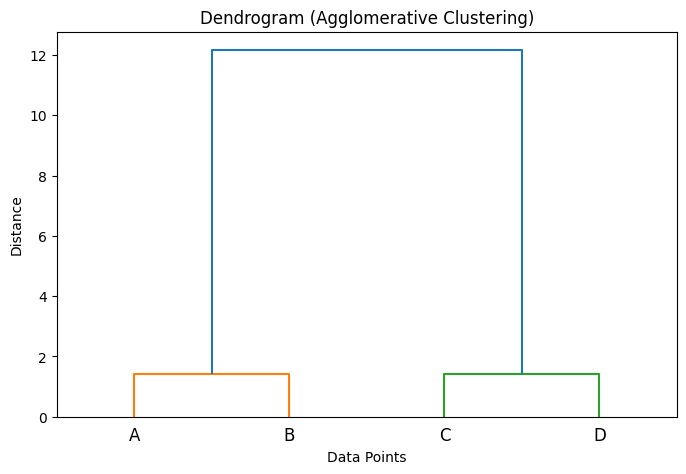

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# Example dataset for 4 clusters (A, B, C, D)
# Each point is labeled implicitly by index
X = np.array([
    [1, 2],   # A
    [2, 3],   # B
    [8, 7],   # C
    [9, 8]    # D
])

labels = ['A', 'B', 'C', 'D']

# Perform Agglomerative Clustering using Ward linkage
Z = linkage(X, method='ward')

# Plot dendrogram
plt.figure(figsize=(8, 5))
dendrogram(Z, labels=labels)

plt.title("Dendrogram (Agglomerative Clustering)")
plt.xlabel("Data Points")
plt.ylabel("Distance")

plt.show()